<a href="https://colab.research.google.com/github/boracandan/Algoverse_Truth_Directions_Research/blob/main/Extract_Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/boracandan/Algoverse_Truth_Directions_Research.git

fatal: destination path 'Algoverse_Truth_Directions_Research' already exists and is not an empty directory.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import pickle
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import gc



In [5]:
import pandas as pd

DATA_DIR = "Algoverse_Truth_Directions_Research/dataset"

F0_train, F0_test = pd.read_csv(f"{DATA_DIR}/F0_train.csv"), pd.read_csv(f"{DATA_DIR}/F0_test.csv")
F1_train, F1_test = pd.read_csv(f"{DATA_DIR}/F1_train.csv"), pd.read_csv(f"{DATA_DIR}/F1_test.csv")
F2_train, F2_test = pd.read_csv(f"{DATA_DIR}/F2_train.csv"), pd.read_csv(f"{DATA_DIR}/F2_test.csv")
F3_train, F3_test = pd.read_csv(f"{DATA_DIR}/F3_train.csv"), pd.read_csv(f"{DATA_DIR}/F3_test.csv")
F4_train, F4_test = pd.read_csv(f"{DATA_DIR}/F4_train.csv"), pd.read_csv(f"{DATA_DIR}/F4_test.csv")
F5_train, F5_test = pd.read_csv(f"{DATA_DIR}/F5_train.csv"), pd.read_csv(f"{DATA_DIR}/F5_test.csv")

A1_train, A1_test = pd.read_csv(f"{DATA_DIR}/A1_train.csv"), pd.read_csv(f"{DATA_DIR}/A1_test.csv")
A2_train, A2_test = pd.read_csv(f"{DATA_DIR}/A2_train.csv"), pd.read_csv(f"{DATA_DIR}/A2_test.csv")
A3_train, A3_test = pd.read_csv(f"{DATA_DIR}/A3_train.csv"), pd.read_csv(f"{DATA_DIR}/A3_test.csv")

for name, df in {"F0_train": F0_train, "F0_test": F0_test,
                  "F1_train": F1_train, "F1_test": F1_test,
                  "F2_train": F2_train, "F2_test": F2_test,
                  "F3_train": F3_train, "F3_test": F3_test,
                  "F4_train": F4_train, "F4_test": F4_test,
                  "F5_train": F5_train, "F5_test": F5_test,
                  "A1_train": A1_train, "A1_test": A1_test,
                  "A2_train": A2_train, "A2_test": A2_test,
                  "A3_train": A3_train, "A3_test": A3_test}.items():
    print(f"{name}: {len(df)} rows")

F0_train: 1194 rows
F0_test: 512 rows
F1_train: 1194 rows
F1_test: 512 rows
F2_train: 1194 rows
F2_test: 512 rows
F3_train: 1398 rows
F3_test: 600 rows
F4_train: 1394 rows
F4_test: 598 rows
F5_train: 1383 rows
F5_test: 593 rows
A1_train: 700 rows
A1_test: 300 rows
A2_train: 700 rows
A2_test: 300 rows
A3_train: 700 rows
A3_test: 300 rows


In [14]:


from google.colab import userdata
from transformers import BitsAndBytesConfig
gc.collect()
torch.cuda.empty_cache()
hf_token = userdata.get("HFKEY")

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct", token=hf_token)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"


bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.1-8B-Instruct",
    quantization_config=bnb_config,
    device_map="cuda",
    token=hf_token
)


model.eval()
print("Model loaded")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded


In [15]:
def activations_all_layers(model,statements, with_chat_template=False, batch_size = 4):
    statements = list(statements)
    num_layers = model.config.num_hidden_layers +1
    activations_by_layer =  [[] for _ in range(num_layers)]

    for i in range(0,len(statements), batch_size):
      batch = statements[i : i + batch_size]

      if with_chat_template :
        messages = [[{"role" :"user","content":s}]for s in batch]
        inputs = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize = True,
            return_dict = True,
            return_tensors="pt",
            padding = True

            ).to(model.device)
      else:
        inputs = tokenizer(batch,return_tensors="pt", padding = True).to(model.device)

      with torch.no_grad():
        outputs = model(**inputs, output_hidden_states = True)


      for layer_idx, layer_hidden in enumerate(outputs.hidden_states):
        final_token = layer_hidden[:,-1,:]
        activations_by_layer[layer_idx].append(final_token.cpu())


    return  [torch.cat(layer_acts, dim=0) for layer_acts in activations_by_layer]




In [16]:
def train_probe(activations, labels, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")):
  (X_train, X_test), (y_train, y_test) = activations , labels

  X_train = torch.stack(list(X_train)).float().numpy()
  X_test = torch.stack(list(X_test)).float().numpy()

  y_train = y_train.to_numpy()
  y_test = y_test.to_numpy()


  train_mean = X_train.mean(axis = 0)

  X_train = X_train - train_mean
  X_test = X_test - train_mean


  X_train_t = torch.tensor(X_train, dtype = torch.float32, device = device)
  y_train_t = torch.tensor(y_train, dtype = torch.float32, device = device)
  X_test_t = torch.tensor(X_test, dtype = torch.float32, device = device)

  hidden_dim = X_train.shape[1]

  probe = nn.Linear(hidden_dim, 1 , bias=False).to(device)


  optimizer = torch.optim.Adam(probe.parameters(), lr = 1e-3, weight_decay=0.1)

  loss_fn = nn.BCEWithLogitsLoss()

  for step in range(1000):
    optimizer.zero_grad()
    logits = probe(X_train_t).squeeze(-1)
    loss = loss_fn( logits, y_train_t)
    loss.backward()
    optimizer.step()
    probe.eval()

  with torch.no_grad():

    test_logits = probe(X_test_t).squeeze(-1).cpu().numpy()

  auroc = roc_auc_score(y_test, test_logits)
  return probe, train_mean,auroc

def train_all_layers(activations_by_layer_train, activations_by_layer_test, y_train , y_test,device = "cuda"):
  num_layer =len(activations_by_layer_train)
  layer_results = {}
  for layer_idx in range(num_layer):
    X_train = activations_by_layer_train[layer_idx]
    X_test = activations_by_layer_test[layer_idx]

    probe, train_mean, auroc = train_probe((X_train,X_test), (y_train, y_test))

    w = probe.weight.detach().cpu().numpy().flatten()
    layer_results[layer_idx] = {"auroc": auroc, "weights": w}
    print(f"  Layer {layer_idx}: AUROC = {auroc:.4f}")
  return  layer_results

In [17]:
tasks = {
    "F0": (F0_train, F0_test),
    "F1": (F1_train, F1_test),
    "F2": (F2_train, F2_test),
    "F3": (F3_train, F3_test),
    "F4": (F4_train, F4_test),
    "F5": (F5_train, F5_test),
    "A1": (A1_train, A1_test),
    "A2": (A2_train, A2_test),
    "A3": (A3_train, A3_test),
}

all_results = {}

for task_name, (train_df, test_df) in tasks.items():
  print(f"\nProcessing {task_name}...")
  print(model.device)
  train_acts = activations_all_layers(
      model, train_df["statement"], with_chat_template=False, batch_size=4
  )
  test_acts = activations_all_layers(
      model, test_df["statement"], with_chat_template=False, batch_size=4
  )


  results = train_all_layers(
      train_acts, test_acts,
      train_df["label"], test_df["label"],
  )

  all_results[task_name] = results
  del train_acts, test_acts
  torch.cuda.empty_cache()

with open("layer_results.pkl", "wb") as f:
  pickle.dump(all_results, f)
print(f"Results saved to layer_results.pkl")



Processing F0...
cuda:0
  Layer 0: AUROC = 0.5000
  Layer 1: AUROC = 0.4747
  Layer 2: AUROC = 0.5065
  Layer 3: AUROC = 0.5112
  Layer 4: AUROC = 0.6319
  Layer 5: AUROC = 0.9256
  Layer 6: AUROC = 0.9475
  Layer 7: AUROC = 0.9543
  Layer 8: AUROC = 0.9771
  Layer 9: AUROC = 0.9959
  Layer 10: AUROC = 0.9995
  Layer 11: AUROC = 0.9997
  Layer 12: AUROC = 0.9997
  Layer 13: AUROC = 0.9998
  Layer 14: AUROC = 0.9998
  Layer 15: AUROC = 0.9998
  Layer 16: AUROC = 0.9995
  Layer 17: AUROC = 0.9995
  Layer 18: AUROC = 0.9994
  Layer 19: AUROC = 0.9994
  Layer 20: AUROC = 0.9993
  Layer 21: AUROC = 0.9993
  Layer 22: AUROC = 0.9993
  Layer 23: AUROC = 0.9993
  Layer 24: AUROC = 0.9992
  Layer 25: AUROC = 0.9992
  Layer 26: AUROC = 0.9991
  Layer 27: AUROC = 0.9992
  Layer 28: AUROC = 0.9991
  Layer 29: AUROC = 0.9991
  Layer 30: AUROC = 0.9991
  Layer 31: AUROC = 0.9991
  Layer 32: AUROC = 0.9993

Processing F1...
cuda:0
  Layer 0: AUROC = 0.5000
  Layer 1: AUROC = 0.4846
  Layer 2: AUROC 

Loaded results for tasks:  ['F0', 'F1', 'F2', 'F3', 'F4', 'F5', 'A1', 'A2', 'A3']


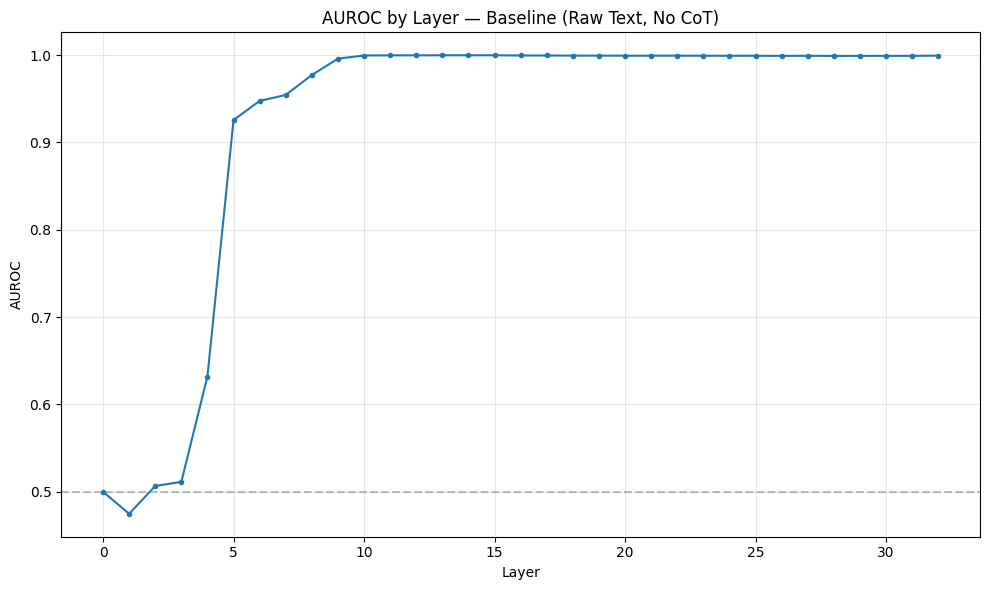

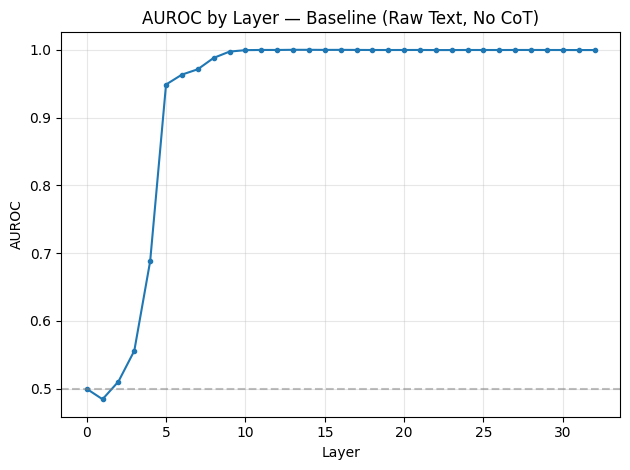

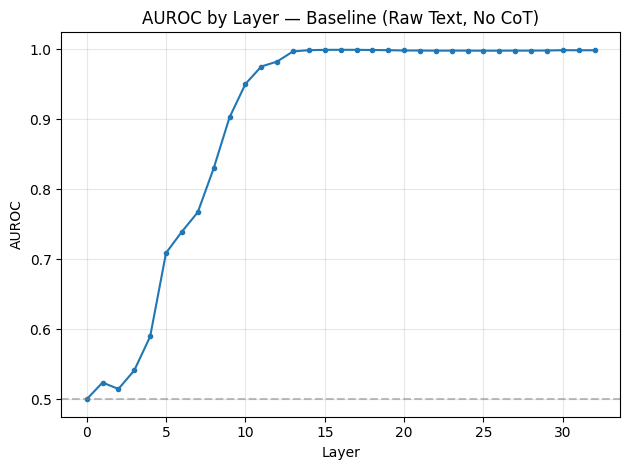

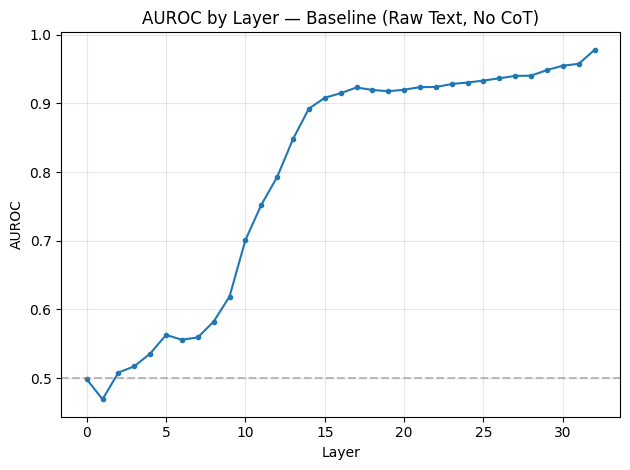

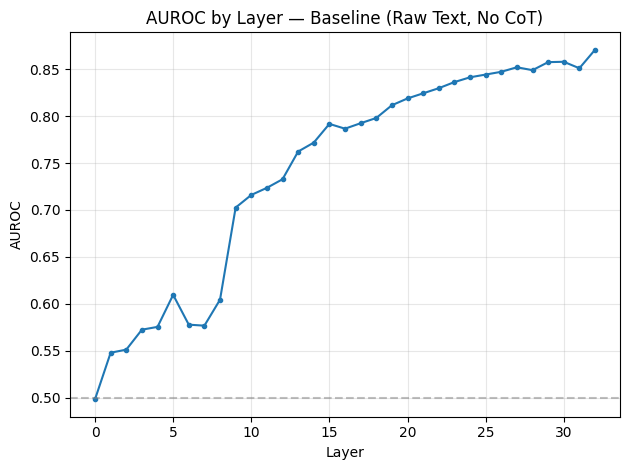

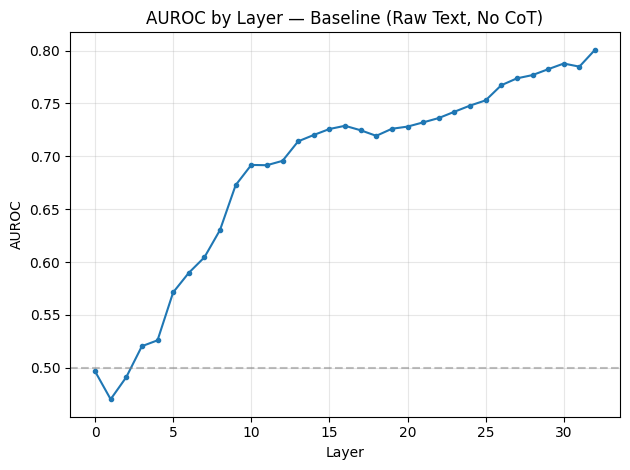

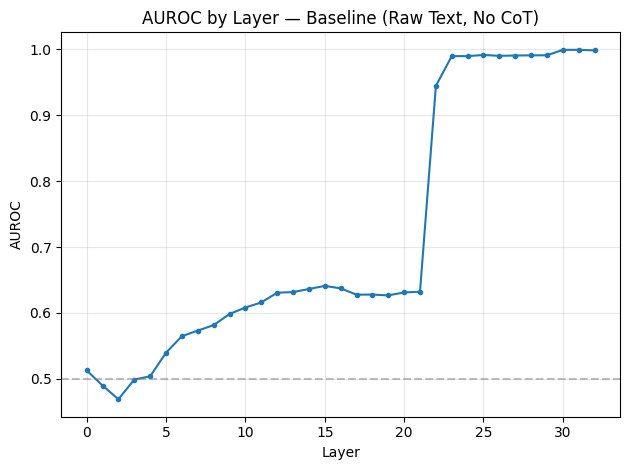

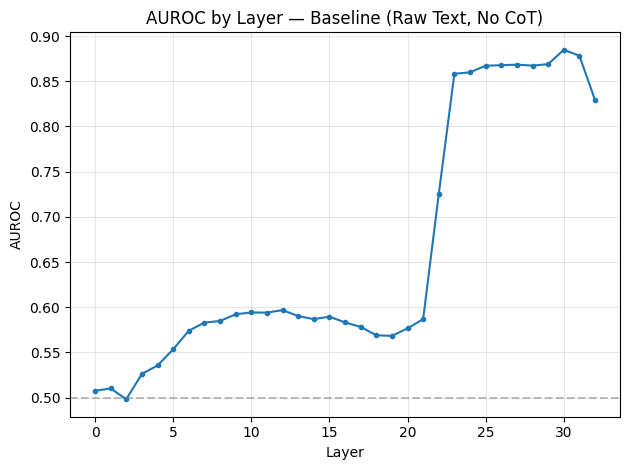

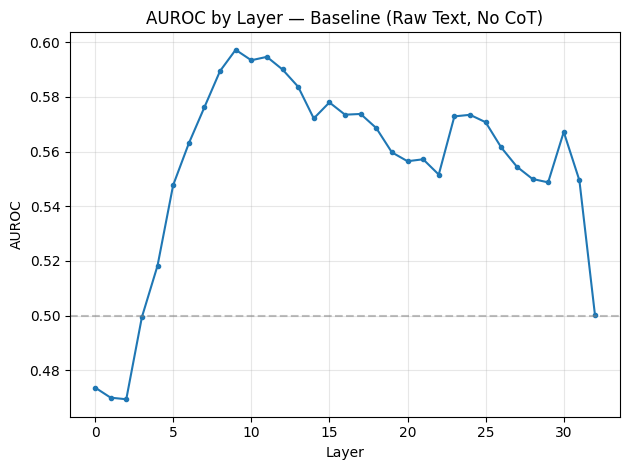

In [18]:
import matplotlib.pyplot as plt

with open("layer_results.pkl", "rb") as f:
  all_results = pickle.load(f)


print("Loaded results for tasks: ", list(all_results.keys()))

def plot_auroc_by_layer(all_results, tasks_to_plot=None ,title="AUROC by Layer"):

  if tasks_to_plot is None:
    tasks_to_plot = list(all_results.keys())

  plt.figure(figsize=(10, 6))

  for task_name in tasks_to_plot:
    layers = sorted(all_results[task_name].keys())
    aurocs =  [all_results[task_name][layer]["auroc"] for layer in layers]



    plt.plot(layers, aurocs, marker='o', markersize=3, label=task_name)
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label="Chance (0.5)")
    plt.xlabel("Layer")
    plt.ylabel("AUROC")

    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("auroc_by_layer.png", dpi=150)
    plt.show()



plot_auroc_by_layer(all_results, title="AUROC by Layer — Baseline (Raw Text, No CoT)")


In [21]:


import numpy as np



def cosine_similarity(w1, w2):


    dot_product = np.dot(w1, w2)


    norm1 = np.linalg.norm(w1)
    norm2 = np.linalg.norm(w2)


    similarity = dot_product / (norm1 * norm2)

    return similarity


def compute_similarity_matrix(all_results, layer, task_names=None):


    if task_names is None:
        task_names = list(all_results.keys())


    n_tasks = len(task_names)
    similarity_matrix = np.zeros((n_tasks, n_tasks))


    for i, task_i in enumerate(task_names):
        for j, task_j in enumerate(task_names):


            w_i = all_results[task_i][layer]["weights"]
            w_j = all_results[task_j][layer]["weights"]


            similarity_matrix[i, j] = cosine_similarity(w_i, w_j)


    return similarity_matrix, task_names



In [22]:
def plot_similarity_heatmap(all_results, layer, task_names=None, title=None):


    matrix, task_names = compute_similarity_matrix(all_results, layer, task_names)


    if title is None:
        title = f"Cosine Similarity Between Probe Directions — Layer {layer}"


    plt.figure(figsize=(8, 7))

    im = plt.imshow(matrix, cmap='RdBu_r', vmin=-1, vmax=1)

    plt.colorbar(im, label="Cosine Similarity")


    plt.xticks(range(len(task_names)), task_names, rotation=45, ha='right')
    plt.yticks(range(len(task_names)), task_names)


    for i in range(len(task_names)):
        for j in range(len(task_names)):
            plt.text(j, i, f"{matrix[i, j]:.2f}",
                     ha='center', va='center',
                     color='white' if abs(matrix[i, j]) > 0.5 else 'black')


    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"similarity_heatmap_layer{layer}.png", dpi=150)
    plt.show()

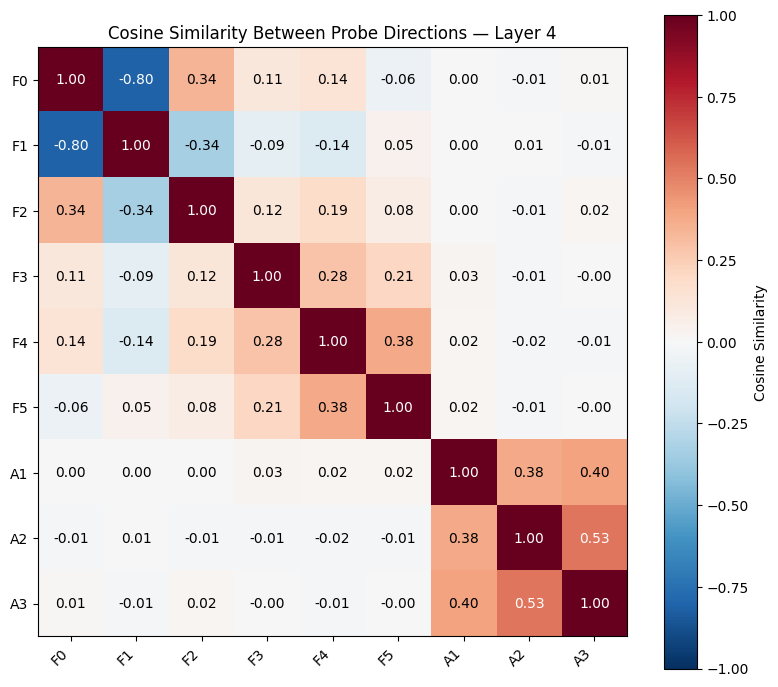

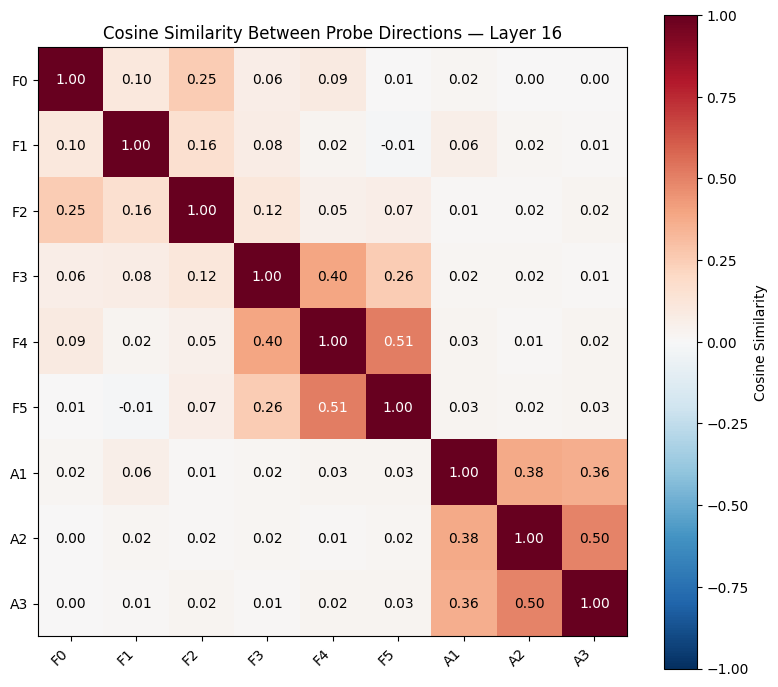

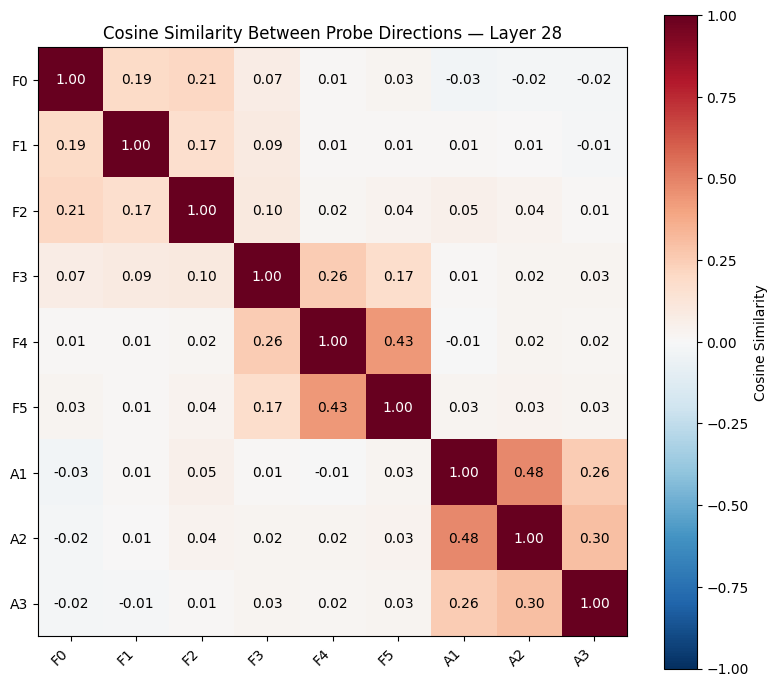

In [23]:


for layer in [4, 16, 28]:
    plot_similarity_heatmap(all_results, layer=layer)